# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [28]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [30]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [31]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [32]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [33]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [34]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [35]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [36]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


## De la inspección de users:

    - Las columnas date y churn_date estan con formato object pero deberian estar como date.

## De la inspeccion de usage:

    -La columna date esta con formato object pero deberia estar como date.

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [37]:
# cantidad de nulos para users:
print(users.isna().sum())

#Proporción de nulos para users:
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [38]:
# cantidad de nulos para usage
print(usage.isna().sum())

#Proporción de nulos para usage:
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?


  **Dataframe users:**
  
-City: tiene 469 valores nulos equivalentes 11,725%


-Churn_date: tiene 3534 valores nulos equivalentes a 88,350%
  
- Indica qué harías: ¿imputar, eliminar, ignorar?

    -En cuanto a la columna City: Nulo real, pero la variable no es relevante para ninguna de las 4 preguntas de negocio (que giran en torno a edad, plan y patrones de uso). Despues de saber que dentro de las ciudades hay registros con '?' se decidió reemplazarlo por pd.NA.

  
    -En cuento a los nulos de Churn_date: los valores nulos pueden corresponder a usuarios activos que aun no se han dado de baja. Luego de hacer el respectivo analisis se encontraron valores con años imposibles por lo cual se procedio a reemplazarlos por nulos de tiempo.


**Valores nulos**  

- ¿Qué columnas tienen valores faltantes y en qué proporción?


  **Dataframe usage:**


           -Date: tiene 50 valores nulos equivalentes al 0,125%

  
          -Duration: tiene 22076 valores nulos equivalentes al 55,190%

  
          -Length: tiene 17896 valores nuelos equivalentes al 44,740%

  
        - Indica qué harías: ¿imputar, eliminar, ignorar?
 
        -Date: como son tan pocos registros: Eliminar esas filas sin impacto en el análisis.

      De acuerdo al analisis hecho en el paso 3.2:

        -Duration: No imputar/eliminar; filtrar por type == 'call' al analizar duración.

        -Length: No imputar/eliminar; filtrar por type == 'text' al analizar longitud.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [39]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` hay 4000 registros (4000 usarios). El resto de información no tiene sentido hallarla porque esta columna indica una identificación, aunque sea numerica.
- La columna `age`se encuentra que su edad minima es -999 lo cual no es posible (valor invalido), lo cual puede afectar el resto de estadisticas.

In [40]:
# Contar el sentinel-999 en la columna Age del df users:
(users['age'] == -999).sum()

55

    # Hay 55 registros sentinels -999 en la columna age, aproximadamente el 1,375%.

In [41]:
# explorar columnas numéricas de usage

usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


    - Las columnas `id` y `user_id`: muestras que hay 40000 registros (40000 usuarios)
    - La columna `duration` valor minimo 0 es decir que la llamada tuvo una duración cero lo cual es un valor invalido, maximo 120, promedio de 5.20
    - La columna `length`valor minimo 0 es decir que un mensaje no tiene caracteres esta vacio, lo cual es un valor invalido, maximo 1490, promedio de 52.12

In [42]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

users[columnas_user].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [43]:
# Revisión del signo '?' en la columna city:

print((users['city'] == '?').sum())


96


- La columna `city` De los 3531 registros con ciudad, hay aproximadamente 7 ciudades únicas (el '?' aparece 96 veces) probablemente haciendo parte de los 7 valores únicos, y Bogotá concentra 808 registros (~23%), lo que sugiere que es la ciudad con mayor presencia de usuarios, pero también hay bastante dispersión hacia las otras 6 ciudades.
- La columna `plan` tiene dos planes básico o premium

In [44]:
# explorar columna categórica de usage
columna_usage = ['type'] 

print(usage[columna_usage].describe())

         type
count   40000
unique      2
top      text
freq    22092


- La columna `type` hay dos valores unidos (text y call), text es el valor que más se repite con 22092.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  

- ¿En qué columnas encontraste valores inválidos o sentinels?
- - ¿Qué acción tomarías? 

    -Se encontraron valores sentinel es la columna city, 96 sentinesl ''?''. Los cuales, deben ser reemplazados por NaN.
 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [45]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [46]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [47]:
# Revisar los años presentes en `reg_date` de users

print(users['reg_date'].dt.year.unique())

[2022 2026 2023 2024]


En `reg_date`, los años resultantes son 2022, 2023, 2024 y 2026, siendo este último imposible ya que los datos registrados son hasta el año 2024.

In [48]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.unique())

[2024.   nan]


En `date`, Solo aparece el año 2024 y valores nan. No hay años fuera de rango, pero sí existen registros sin fecha (missing values) que deben tratarse por separado, ya que representan uso sin fecha registrada, no una fecha inválida como tal.

Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? Sí, en reg_date aparece 2026, un año futuro respecto al límite de datos (2024), lo cual es imposible dado que no puede haber un registro de usuario fechado después del momento en que se guardaron los datos.

- ¿Qué harías con ellas?: primero cuantificar cuántos registros tienen reg_date con año 2026

In [49]:
# Cantidad de registros año 2026:

(users['reg_date'].dt.year == 2026).sum()

40

    # Despues de cuantificar el número de registros con el año 2026, se puede dectectar que 40 registros son aproximadamente el 1%, una proporción muy pequeña, la cual se puede reemplazar con valor nulo.

In [50]:
# Revisar missing values en Date:

usage['date'].isna().sum()

50

    # Despues de revisar la columna date se encontraron 50 registros sin fecha. En el siguiente paso esos registros serán reemplazados con NaT.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [51]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [52]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [53]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()


count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [54]:
# Verificación MAR en usage (Missing At Random) para duration

# ¿Cuáles son los tipos de uso?
print(usage['type'].value_counts())

# ¿Los nulos de duration coinciden con ciertos tipos?
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

text    22092
call    17908
Name: type, dtype: int64
type
call        0
text    22076
Name: duration, dtype: int64


In [55]:
# Verificación MAR en usage (Missing At Random) para length

print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))

type
call    17896
text        0
Name: length, dtype: int64


**Diagnostico:** 

`duration`: nulo casi exclusivamente cuando type == 'text' (22,076 de 22,092 mensajes). Un mensaje de texto no tiene duración. 
    
    -12 llamadas con length registrada (cuando debería ser nula).

`length`:  nulo casi exclusivamente cuando type == 'call' (17,896 de 17,908 llamadas). Una llamada no tiene longitud de texto.
    
    -16 mensajes de texto con duration registrada (cuando debería ser nula).

In [56]:
#¿Cómo se distribuyen duration en llamadas? 

usage[usage['type'] == 'call']['duration'].describe()

count    17908.000000
mean         5.099671
std          5.922735
min          0.000000
25%          1.430000
50%          3.500000
75%          6.970000
max        120.000000
Name: duration, dtype: float64

In [57]:
#¿Cómo se distribuyen length en textos? 

usage[usage['type'] == 'text']['length'].describe()

count    22092.000000
mean        51.346370
std         45.638659
min          0.000000
25%         37.000000
50%         50.000000
75%         64.000000
max       1490.000000
Name: length, dtype: float64

In [58]:
    # ¿Son MAR? Sí. La cantidad de nulos en duration y length está casi perfectamente explicada por la columna type, que es una variable observada (no oculta) del dataset.
    
    ##duration es nulo casi únicamente cuando tipo es igual a text  22076 de 22092 casos.
        
    ##length es nulo casi únicamente cuando tipo es igual a call 17896 de 17908 casos.

    #Justificación de la decisión (dejar como nulos):

    ##Una llamada (call) no tiene una "longitud de texto" (length), y un mensaje de texto (text) no tiene una "duración" (duration). No es que el dato se perdió por un error de captura: el campo simplemente no aplica a ese tipo de registro.  

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [59]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)  # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)  # conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head()

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [60]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [61]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
users.head()
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [62]:
# Resumen estadístico de las columnas numéricas

user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


    # Sobre los nulos (count = 4000 vs 3999):
    
Hay 1 usuario cuyo count en las columnas de uso es 3999 en lugar de 4000, lo que indica que ese usuario no tiene ningún registro en usage (no aparece en usage_agg tras el merge).

    #Sobre la distribución (¿outliers en cant_minutos_llamada?):
    
Sí, es muy probable que existan outliers. La media (aprox 23.3) está bastante alejada del máximo (155.69) y también se aleja de la mediana (19.78) y el percentil 75% (31.4). Esto sugiere que hay algunos usuarios con un consumo de minutos mucho más alto que el resto, "jalando" la media hacia arriba.

    #Sobre mediana vs media (cant_mensajes: mediana=5, media=5.52)
    
La diferencia es pequeña, lo que sugiere que la distribución de cant_mensajes es casi simétrica.

In [63]:
# Distribución porcentual del tipo de plan

print((user_profile['plan'].value_counts(normalize=True) * 100).round(2))

Basico     64.88
Premium    35.12
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

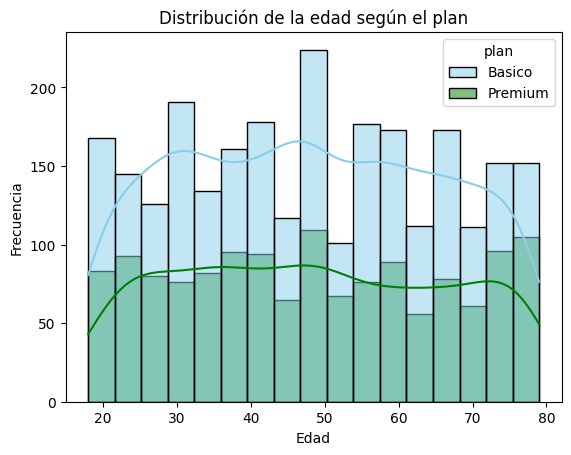

In [64]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)

plt.title('Distribución de la edad según el plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución de ambos planes muy similares a lo largo del gráfico, se observa distribución parecida entre todas las edades (jovenes y adjultos). El plan Básico tiene mayor frecuencia ya que representa el 64.88% de los usuarios. La distribución es aproximadamente simétrica, sin sesgo marcado hacia la izquierda o derecha, aunque se nota un pico leve alrededor de los 45-50 años en ambos planes.

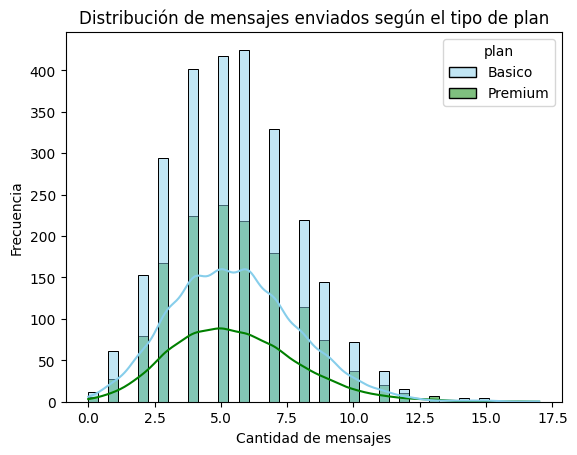

In [65]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de mensajes enviados según el tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Se visualiza un sesgo a la derecha en ambos planes, la mayoria de usuarios envian entre 3 y 8 mensajes. La cola va hacia los valores 10 y 17 mensajes. El plan Básico concentra su pico entre 5-6 mensajes, mientras que Premium tiene un pico similar pero con menor frecuencia absoluta (coherente con que representa menos usuarios).

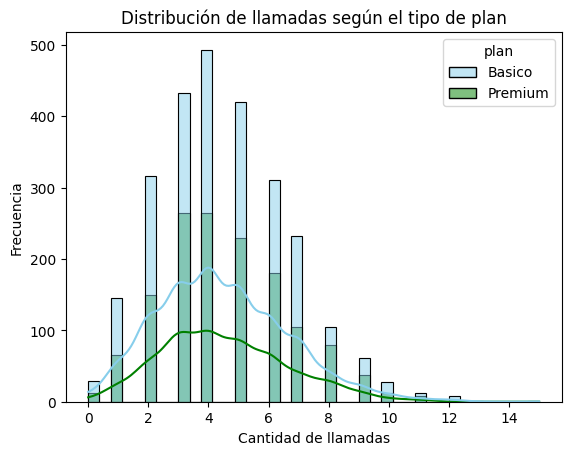

In [66]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de llamadas según el tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución se ilustra un sesgo a la derecha la mayoria de usuarios hacen entre 3 y 6 llamadas. La cola va hacia los valores 8 y 14 llamadas. Ambos planes muestran un pico similar alrededor de las 4 llamadas, con Básico superando en frecuencia a Premium en todo el rango (consistente con su mayor proporción de usuarios).

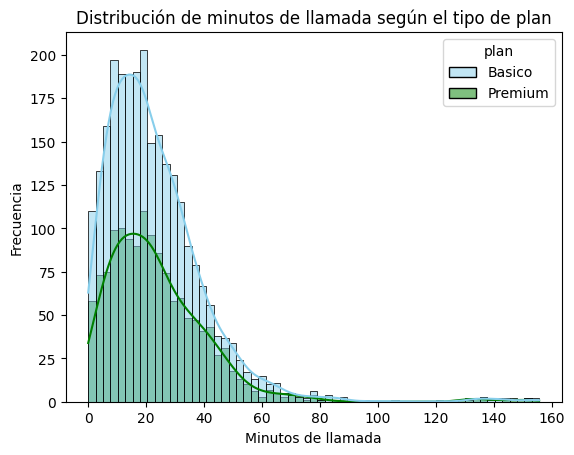

In [67]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de minutos de llamada según el tipo de plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- En este gráfico la cola hacia la derecha es más pronunciada la mayoria de los usuarios consumen en llamadas entre 5 y 30 minutos. Hay una cola hacia la derecha hasta más de 150 minutos, lo que confirma los outliers detectados antes en el resumen estadístico (máx. 155.69 vs media ~23.3): un grupo pequeño de usuarios con consumo de minutos muy por encima del resto, distribuidos en ambos planes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

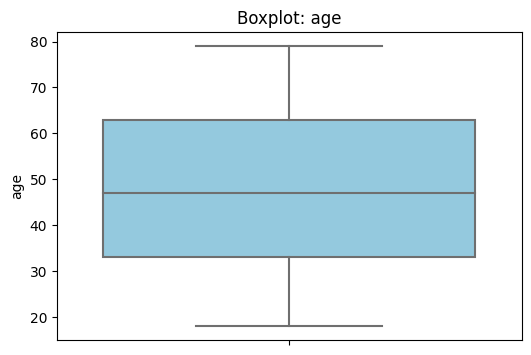

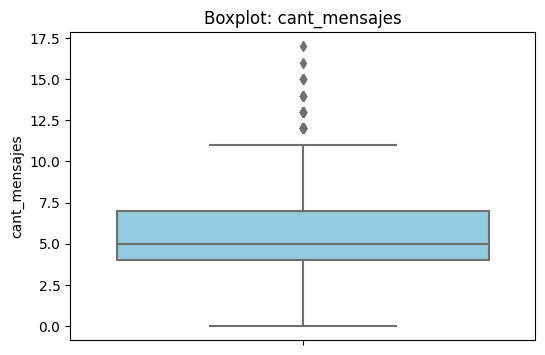

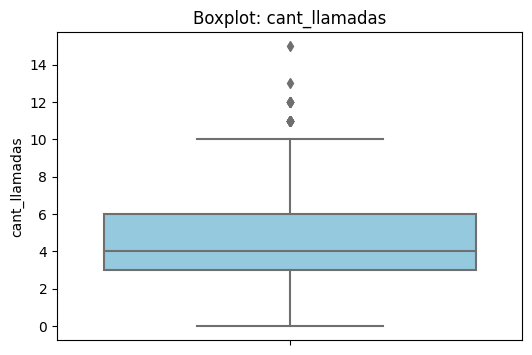

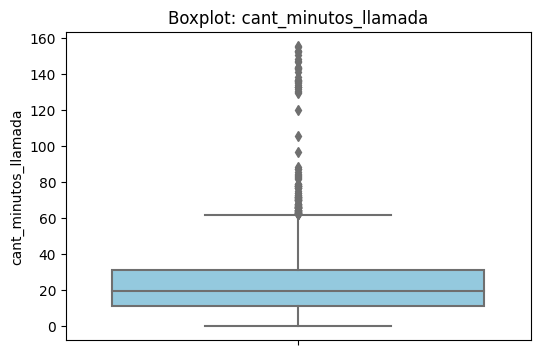

In [68]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=user_profile, y=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()       


💡Insights: 
- Age: no presenta outliers como vimos en el anterior gráfico su distribución es bastante uniforme. 
- cant_mensajes: si hay outliers despues de 12 mensajes, histograma con sesgo a la derecha.
- cant_llamadas: si hay outliers despues de 10 llamadas, histrograma con sesgo a la derecha.
- cant_minutos_llamada: si hay bastantes outliers, histrograma con sesgo marcado a la derecha.

In [69]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    
    n_outliers = (user_profile[col] > limite_superior).sum()
    
    print(f'{col}: límite superior = {limite_superior:.2f} | outliers detectados = {n_outliers}')



cant_mensajes: límite superior = 11.50 | outliers detectados = 46
cant_llamadas: límite superior = 10.50 | outliers detectados = 30
cant_minutos_llamada: límite superior = 61.86 | outliers detectados = 109


In [70]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener ya que representan usuarios con mayor actividad de mensajería. Eliminarlos haría perder información valiosa sobre usuarios más activos.
- cant_llamadas: mantener son usuarios con mayor cantidad de llamadas, comportamiento válido dentro del contexto de uso de un servicio de telecomunicaciones, no un error de datos.
- cant_minutos_llamada: mantener, tiene la mayor cantidad de outliers (109, ~2.73%) y también la mayor distancia entre el límite superior (61.86) y el máximo observado (155.69), reafirmando que es la variable más asimétrica de las tres — consistente con lo que se vio en el histograma.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [71]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'  

user_profile.loc[
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
    'grupo_uso'
] = 'Uso medio'

user_profile.loc[
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'grupo_uso'
] = 'Bajo uso'

# Verificar el resultado
user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

In [72]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [73]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'

user_profile.loc[
    user_profile['age'] < 60,
    'grupo_edad'
] = 'Adulto'

user_profile.loc[
    user_profile['age'] < 30,
    'grupo_edad'
] = 'Joven'

# Verificar el resultado
user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [74]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

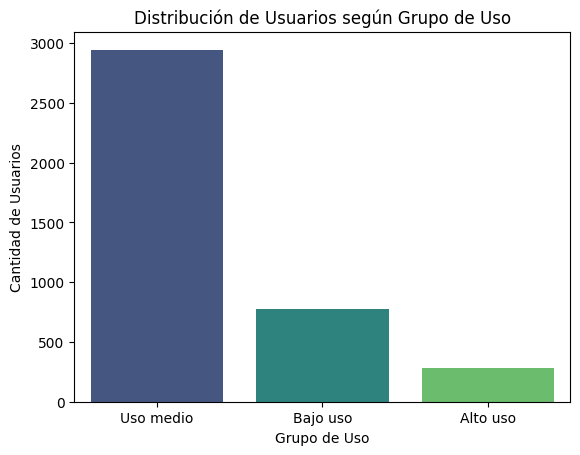

In [75]:
# Visualización de los segmentos por uso
sns.countplot(x='grupo_uso', data=user_profile, order=user_profile['grupo_uso'].value_counts().index, palette='viridis')
plt.title('Distribución de Usuarios según Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()

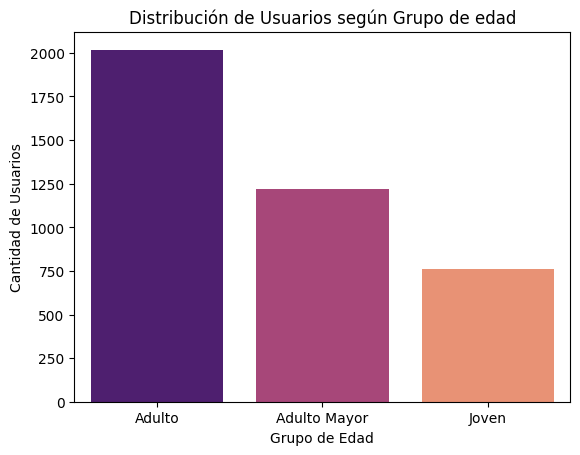

In [76]:
# Visualización de los segmentos por edad
sns.countplot(x='grupo_edad', data=user_profile, order=user_profile['grupo_edad'].value_counts().index, palette='magma')
plt.title('Distribución de Usuarios según Grupo de edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

• ¿Qué problemas tenían originalmemte los datos? ¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

-La columna date tenía formato object. Solo aparecieron el año 2024 y valores nan, existían 50 registros sin fecha (missing values) representando aproximadamente el 0,125%.

-La columna duration tenía 22076 valores nulos, un 55,190%

-La columna length tenía 17896 registros nulos, un 44,740%

-La columna city tenía 469 registros nulos un 11,725%. Además, había 96 registros con el nombre de ciudad ‘?’

-La columna reg_date tenían formato object. Además, había 40 registros con fecha imposible (el año 2026) representando aproximadamente el 1%.

-La columna churn_date tenían formato object. Además, tenía 3534 valores nulos un 88,350%

-La columna age tenía 55 registros sentinels -999, aproximadamente el 1,375%.



	
🔍 **Segmentos por Edad**
•	¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

-El comportamiento de los 4000 usuarios según su edad:

    -'Adulto mayor' >= 60: 1222 usuarios

    -'Adulto' < 60: 2018 usuarios 

    -'Joven' < 30: 760 usuarios 


📊 **Segmentos por Nivel de Uso**

-De 4000 usuarios el 64.88% usan el plan básico y el 35.12% usan premium.

-El comportamiento de los 4000 usuarios según el uso:

    -'Bajo uso' cuando llamadas < 5 y mensajes < 5: 778 usuarios 

    -'Uso medio' cuando llamadas < 10 y mensajes < 10: 2943 usuarios

    -'Alto uso' para el resto de casos: 279 usuarios



➡️ Esto sugiere que

**Por edad:**

-La base de usuarios es mayoritariamente adulta: Adulto (50.5%) y Adulto mayor (30.5%) suman más del 80% del total, mientras que los Jóvenes solo son el 19%.

-Esto indica un perfil de cliente maduro, lo cual puede influir en preferencias de uso (menor familiaridad tecnológica, uso más conservador del plan, etc)


**Por nivel de uso:**


-La mayoría (73.6%) tiene un uso medio, es decir, el comportamiento "típico" domina la base de usuarios.

-Solo un 7% son de alto uso, lo que sugiere una oportunidad: son candidatos naturales para el plan premium o para campañas de upselling.

-El 19.45% de bajo uso podría representar riesgo de abandono (churn) o usuarios que no están aprovechando el servicio.


💡 **Recomendaciones**

•	¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

-Usuarios de alto uso (7%, 279 usuarios): son el segmento más valioso porque generan el mayor volumen de actividad (llamadas, mensajes, minutos). Si están en plan básico, representan la oportunidad de upsell más clara y directa. 

-Adultos (50.5% de la base): por ser el grupo más numeroso, cualquier estrategia dirigida a ellos tiene el mayor impacto en ingresos totales, aunque su uso sea "medio". 

-Usuarios con minutos de llamada muy altos (los 109 outliers): probablemente dependen del servicio de voz más que del de datos/mensajes — un perfil distinto y valioso para retención.


•	¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

-Minutos de llamada: 109 outliers (límite > 61.86 min): es la variable con más valores extremos, casi el doble que las otras dos combinadas. Esto sugiere que hay un subgrupo de usuarios que usa el servicio principalmente para llamadas largas.

-Mensajes: 46 outliers (límite > 11.5): un grupo más pequeño con uso intensivo de mensajería.

-Llamadas (cantidad): 30 outliers (límite > 10.5): el grupo más chico, hacen muchas llamadas, pero probablemente cortas si no coincide 1:1 con los outliers de minutos.

Implicación para el negocio: el uso extremo está concentrado en voz (minutos), no en mensajes. Esto sugiere que ConnectaTel tiene una base de usuarios que valora la llamada tradicional por encima del mensaje — importante si están pensando en planes orientados a datos/mensajería.


•	¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

-Plan "Voz Ilimitada": dirigido a los 109 outliers de minutos. Un plan con minutos ilimitados o un umbral más alto podría mejorar retención y aumentar ingresos si se posiciona como premium. 

-Plan intermedio entre básico y premium: dado que el 73.6% está en "uso medio", un plan que cubra ese rango específico (en vez de solo básico/premium) podría reducir el riesgo de que se sientan "apretados" en básico o paguen de más en premium. 

-Revisar el plan básico para adultos mayores de bajo uso: si este segmento (bajo uso, 19.45%) coincide con adultos mayores, ofrecerles un plan económico simplificado podría reducir el churn sin sacrificar ingresos, ya que probablemente no necesitan más capacidad. 


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`